In [1]:
pip install pandas

In [2]:
pip install scikit-learn

In [3]:
from sklearn.datasets import load_iris
import pandas as pd


In [8]:
iris = load_iris()

In [9]:
print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [10]:
df=pd.DataFrame(iris['data'],columns=iris['feature_names'])

In [11]:
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [12]:
print(df.to_string())

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
5                  5.4               3.9                1.7               0.4
6                  4.6               3.4                1.4               0.3
7                  5.0               3.4                1.5               0.2
8                  4.4               2.9                1.4               0.2
9                  4.9               3.1                1.5               0.1
10                 5.4               3.7                1.5               0.2
11                 4.8               3.4                1.6     

In [13]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3
149,5.9,3.0,5.1,1.8


In [14]:
df["species"]=iris.target

In [15]:
df["species"]=df["species"].map({0:"setosa",1:"versicolor",2:"virginica"})

In [17]:
print(df.head())

   sepal length (cm)  sepal width (cm)  ...  petal width (cm)  species
0                5.1               3.5  ...               0.2   setosa
1                4.9               3.0  ...               0.2   setosa
2                4.7               3.2  ...               0.2   setosa
3                4.6               3.1  ...               0.2   setosa
4                5.0               3.6  ...               0.2   setosa

[5 rows x 5 columns]


In [18]:
print(df.tail)

<bound method NDFrame.tail of      sepal length (cm)  sepal width (cm)  ...  petal width (cm)    species
0                  5.1               3.5  ...               0.2     setosa
1                  4.9               3.0  ...               0.2     setosa
2                  4.7               3.2  ...               0.2     setosa
3                  4.6               3.1  ...               0.2     setosa
4                  5.0               3.6  ...               0.2     setosa
..                 ...               ...  ...               ...        ...
145                6.7               3.0  ...               2.3  virginica
146                6.3               2.5  ...               1.9  virginica
147                6.5               3.0  ...               2.0  virginica
148                6.2               3.4  ...               2.3  virginica
149                5.9               3.0  ...               1.8  virginica

[150 rows x 5 columns]>


In [19]:
print(df.to_string())

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)     species
0                  5.1               3.5                1.4               0.2      setosa
1                  4.9               3.0                1.4               0.2      setosa
2                  4.7               3.2                1.3               0.2      setosa
3                  4.6               3.1                1.5               0.2      setosa
4                  5.0               3.6                1.4               0.2      setosa
5                  5.4               3.9                1.7               0.4      setosa
6                  4.6               3.4                1.4               0.3      setosa
7                  5.0               3.4                1.5               0.2      setosa
8                  4.4               2.9                1.4               0.2      setosa
9                  4.9               3.1                1.5               0.1      setosa
10        

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [21]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


In [22]:
df.duplicated().sum()

np.int64(1)

In [23]:
df.drop_duplicates(inplace=True)

In [24]:
X=df.drop("species",axis=1)
y=df["species"]

In [25]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [27]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [29]:
y_pred=model.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 1.0


In [31]:
from sklearn.metrics import confusion_matrix
confusion=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:\n",confusion)

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [32]:
from sklearn.metrics import classification_report
report=classification_report(y_test,y_pred)
print("Classification Report:\n",report)

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [33]:
import matplotlib.pyplot as plt


In [34]:
plt.figure(figsize=(8,6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

Text(0.5, 1.0, 'Distribution of Sepal Lengths')

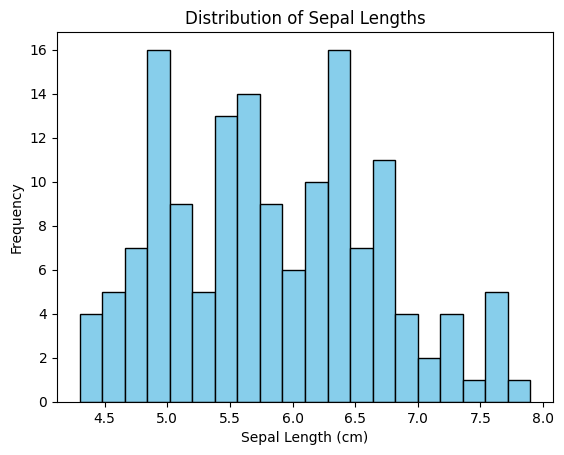

In [55]:
plt.hist(df["sepal length (cm)"],bins=20,color="skyblue",edgecolor="black")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Frequency")
plt.title("Distribution of Sepal Lengths")


In [48]:
# Convert 'species' to numeric for coloring the scatter plot
y_numeric = df["species"].map({"setosa":0,"versicolor":1,"virginica":2})

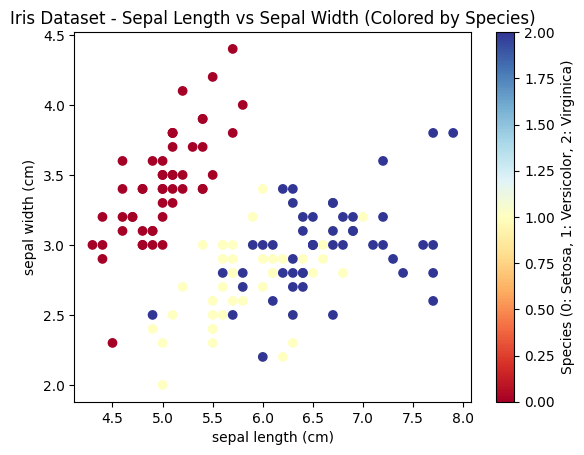

In [49]:
plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=y_numeric,
    cmap='RdYlBu'
)
plt.xlabel(X.columns[0]) # Label x-axis with the first feature name
plt.ylabel(X.columns[1]) # Label y-axis with the second feature name
plt.title('Iris Dataset - Sepal Length vs Sepal Width (Colored by Species)') # Add a title
plt.colorbar(label='Species (0: Setosa, 1: Versicolor, 2: Virginica)') # Add color bar for legend
plt.show()